In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df= pd.read_csv('products_asos.csv', on_bad_lines='skip')
df['price']= pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])

print(f"data loaded: {len(df)} rows")
df.head()

data loaded: 18378 rows


,url,name,size,category,price,color,sku,description,images
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...


In [52]:
def get_brand(text):
    # Check if it's a list/dict structure and extract the Product Details
    if isinstance(text, list) and len(text) > 0:
        if isinstance(text[0], dict) and 'Product Details' in text[0]:
            text = text[0]['Product Details']

    # Now process the text
    text = str(text)
    if 'by' in text:
        try:
            return text.split('by')[1].strip().split(' ')[0]
        except:
            return "unknown"
    return "unknown"

# Re-run this
df['brand_raw'] = df['description'].apply(get_brand)
print(df['brand_raw'].head(20))


0                    New
1                    New
2                    New
3                    New
4     StradivariusJacket
5     StradivariusJacket
6     StradivariusJacket
7     StradivariusJacket
8             JDYLow-key
9             JDYLow-key
10                  Nike
11                  Nike
12                  Nike
14                  ASOS
15                  ASOS
16                  ASOS
17                  ASOS
18                  ASOS
19                  ASOS
20                  ASOS
Name: brand_raw, dtype: object


In [53]:
df.head(3)

,url,name,size,category,price,color,sku,description,images,brand_raw,Brand
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New,
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New,
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New,


In [54]:
brand_map= {
    'New':'New Look',
    'River': 'River Island',
    'Miss': 'Miss Selfridge',
    'TopshopeWelcome': 'Topshope'
}


In [55]:
df['Brand']= df['brand_raw'].map(brand_map).fillna(df['brand_raw'])

brand_counts = df['Brand'].value_counts()
valid_brands = brand_counts[brand_counts >5].index
df_clean = df[df['Brand'].isin(valid_brands)].copy()


print(df_clean['Brand'].value_counts().head(5))

Brand
ASOS              4844
TopshopWelcome     711
New Look           511
River Island       474
Miss Selfridge     429
Name: count, dtype: int64


In [56]:
def calculate_phantom_revenue(size_str):
  if not isinstance(size_str, str):
    return 0, 0.0


  sizes= size_str.split(",")
  total_sizes = len(sizes)

  out_of_stock_count = size_str.count('Out of stock')

  rate= out_of_stock_count / total_sizes if total_sizes > 0 else 0.0

  return out_of_stock_count, rate

metrics= df_clean['size'].apply(lambda x:calculate_phantom_revenue(x))

df_clean['stockout_count']= [x[0] for x in metrics]
df_clean['stockout_rate']=[x[1] for x in metrics]

df_clean['lost_revenue']= df_clean['price'] * df_clean['stockout_count']

cols= ['Brand','name','price','stockout_count','lost_revenue']
print(df_clean[cols].sort_values(by='lost_revenue',ascending=False).head(5))

                Brand                                               name  \
2941          Barbour               Barbour Beadnell wax jacket in black   
21948  TopshopWelcome  Topshop premium real leather collared zip thro...   
2715             ASOS  ASOS DESIGN premium real leather trench coat i...   
15584            ASOS  ASOS EDITION geo embellished fringe plunge mid...   
29838  TopshopWelcome           Topshop Baggy co-ord jeans in green cord   

       price  stockout_count  lost_revenue  
2941   219.0               9        1971.0  
21948  260.0               7        1820.0  
2715   220.0               7        1540.0  
15584  250.0               6        1500.0  
29838   50.0              27        1350.0  


/tmp/ipykernel_6251/3730204508.py:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


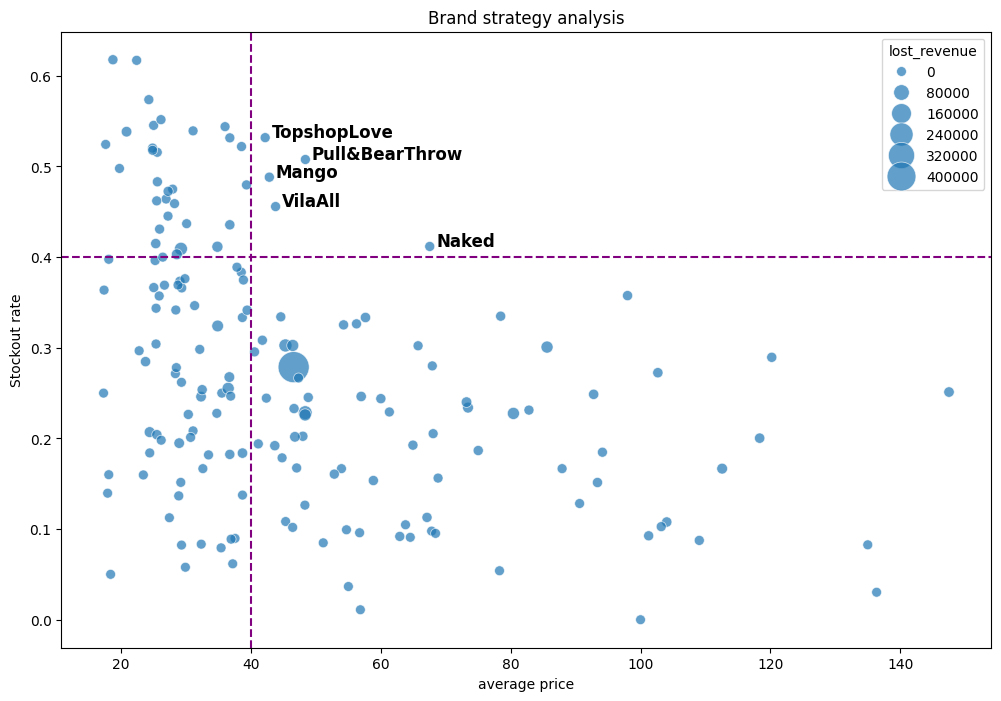

In [64]:
brand_strategy= df_clean.groupby('Brand').agg({
    'price': 'mean',
    'stockout_rate': 'mean',
    'lost_revenue': 'sum',
    'name': 'count'
}).reset_index()


brand_strategy = brand_strategy[brand_strategy['name']>10]

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=brand_strategy,
    x='price',
    y='stockout_rate',
    size='lost_revenue',
    sizes=(50,500),
    alpha=0.7,
    palette='viridis'
 )

winners= brand_strategy[
    (brand_strategy['price'] > 40) &
    (brand_strategy['stockout_rate']>0.4)
]

for i in range(len(winners)):
    plt.text(
        winners.iloc[i]['price']+1,
        winners.iloc[i]['stockout_rate'],
        winners.iloc[i]['Brand'],
        fontsize=12,
        color='black',
        fontweight='bold'
    )

plt.title ('Brand strategy analysis')
plt.xlabel('average price')
plt.ylabel('Stockout rate')
plt.axvline(x=40, color='purple', linestyle='--')
plt.axhline(y=0.4, color='purple', linestyle='--')
plt.show()


In [50]:
print(df['brand_raw'].head(20))

0     
1     
2     
3     
4     
5     
6     
7     
8     
9     
10    
11    
12    
14    
15    
16    
17    
18    
19    
20    
Name: brand_raw, dtype: object


In [51]:
print(df['description'].head(3))

0    [{'Product Details': 'Coats & Jackets by New L...
1    [{'Product Details': 'Coats & Jackets by New L...
2    [{'Product Details': 'Coats & Jackets by New L...
Name: description, dtype: object
